# E-Commerce Q4 Data Analysis

## Task 1: Customer Engagement Tier Analysis

This notebook analyzes e-commerce transactions from 2022-2024 to:
1. Assign engagement tiers based on customer purchase history
2. Calculate total revenue by tier
3. Visualize monthly revenue trends by region
4. Create a bar chart comparing revenue by category (2024 data only)

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

## Step 1: Load and Explore the Data

In [2]:
# Load the CSV data
df = pd.read_csv('Ecom Q4 Dataset - Public - Dummy_E-commerce_Transactions.csv')

# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset info
print("\nDataset Info:")
print(df.info())

# Display basic statistics
print("\nBasic Statistics:")
display(df.describe())

First 5 rows of the dataset:


,Customer ID,Transaction Date,Transaction Amount,Category,Region
0,CUST029,2022-01-03,380.79,Clothing,East
1,CUST007,2022-01-06,951.21,Books,South
2,CUST071,2022-01-06,734.67,Health,North
3,CUST063,2022-01-12,602.67,Home,West
4,CUST058,2022-01-13,164.46,Health,East



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer ID         500 non-null    str    
 1   Transaction Date    500 non-null    str    
 2   Transaction Amount  500 non-null    float64
 3   Category            500 non-null    str    
 4   Region              500 non-null    str    
dtypes: float64(1), str(4)
memory usage: 19.7 KB
None

Basic Statistics:


,Transaction Amount
count,500.000000
mean,503.576220
std,295.701548
min,15.010000
25%,248.865000
50%,518.030000
75%,758.567500
max,993.040000


In [3]:
# Convert Transaction Date to datetime and sort by date
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df = df.sort_values(['Customer ID', 'Transaction Date']).reset_index(drop=True)

print(f"Date range: {df['Transaction Date'].min()} to {df['Transaction Date'].max()}")
print(f"Total transactions: {len(df)}")
print(f"Unique customers: {df['Customer ID'].nunique()}")

Date range: 2022-01-03 00:00:00 to 2024-12-29 00:00:00
Total transactions: 500
Unique customers: 147


## Step 2: Calculate Previous Purchases and Assign Engagement Tiers

### Methodology:
For each transaction, we determine how many purchases that customer had made **before** that transaction:
- **New**: First purchase (0 previous purchases)
- **Active**: 1-4 previous purchases
- **Power User**: 5+ previous purchases

In [4]:
# Calculate cumulative count of purchases for each customer
# Group by Customer ID and use cumcount to get the number of previous transactions
df['Previous Purchases'] = df.groupby('Customer ID').cumcount()

# Display sample to verify
print("Sample of previous purchases calculation:")
sample_customer = df.groupby('Customer ID').size().idxmax()  # Customer with most transactions
display(df[df['Customer ID'] == sample_customer][['Customer ID', 'Transaction Date', 'Transaction Amount', 'Previous Purchases']])

Sample of previous purchases calculation:


,Customer ID,Transaction Date,Transaction Amount,Previous Purchases
232,CUST068,2022-04-13,687.39,0
233,CUST068,2022-08-21,763.18,1
234,CUST068,2022-08-26,433.27,2
235,CUST068,2022-11-13,229.89,3
236,CUST068,2023-02-12,836.95,4
237,CUST068,2023-08-06,852.63,5
238,CUST068,2023-11-02,223.66,6
239,CUST068,2023-11-29,35.10,7
240,CUST068,2024-01-29,255.25,8
241,CUST068,2024-02-20,106.86,9


In [5]:
# Define function to assign engagement tier
def assign_tier(previous_purchases):
    """
    Assign engagement tier based on number of previous purchases:
    - New: First purchase (0 previous purchases)
    - Active: 1-4 previous purchases
    - Power User: 5+ previous purchases
    """
    if previous_purchases == 0:
        return 'New'
    elif previous_purchases <= 4:
        return 'Active'
    else:
        return 'Power User'

# Apply the tier assignment
df['Engagement Tier'] = df['Previous Purchases'].apply(assign_tier)

# Display distribution of tiers
print("Engagement Tier Distribution:")
print(df['Engagement Tier'].value_counts())

# Display sample with tier assignment
print("\nSample data with Engagement Tier:")
display(df[df['Customer ID'] == sample_customer][['Customer ID', 'Transaction Date', 'Transaction Amount', 'Previous Purchases', 'Engagement Tier']])

Engagement Tier Distribution:
Engagement Tier
Active        315
New           147
Power User     38
Name: count, dtype: int64

Sample data with Engagement Tier:


,Customer ID,Transaction Date,Transaction Amount,Previous Purchases,Engagement Tier
232,CUST068,2022-04-13,687.39,0,New
233,CUST068,2022-08-21,763.18,1,Active
234,CUST068,2022-08-26,433.27,2,Active
235,CUST068,2022-11-13,229.89,3,Active
236,CUST068,2023-02-12,836.95,4,Active
237,CUST068,2023-08-06,852.63,5,Power User
238,CUST068,2023-11-02,223.66,6,Power User
239,CUST068,2023-11-29,35.10,7,Power User
240,CUST068,2024-01-29,255.25,8,Power User
241,CUST068,2024-02-20,106.86,9,Power User


## Step 3: Calculate Total Revenue by Engagement Tier

In [6]:
# Calculate total revenue by tier
revenue_by_tier = df.groupby('Engagement Tier')['Transaction Amount'].sum().round(2)

# Display results
print("="*50)
print("TOTAL REVENUE BY ENGAGEMENT TIER")
print("="*50)
for tier in ['New', 'Active', 'Power User']:
    print(f"Revenue for '{tier}' customers: ${revenue_by_tier[tier]:,.2f}")

print(f"\nTotal Revenue: ${revenue_by_tier.sum():,.2f}")
print("="*50)

TOTAL REVENUE BY ENGAGEMENT TIER
Revenue for 'New' customers: $70,954.36
Revenue for 'Active' customers: $161,816.89
Revenue for 'Power User' customers: $19,016.86

Total Revenue: $251,788.11


In [7]:
# Create a summary DataFrame
tier_summary = pd.DataFrame({
    'Engagement Tier': ['New', 'Active', 'Power User'],
    'Total Revenue': [revenue_by_tier['New'], revenue_by_tier['Active'], revenue_by_tier['Power User']],
    'Transaction Count': [df[df['Engagement Tier'] == tier].shape[0] for tier in ['New', 'Active', 'Power User']],
    'Avg Transaction': [df[df['Engagement Tier'] == tier]['Transaction Amount'].mean().round(2) for tier in ['New', 'Active', 'Power User']]
})

tier_summary['Revenue %'] = (tier_summary['Total Revenue'] / tier_summary['Total Revenue'].sum() * 100).round(2)

print("\nEngagement Tier Summary:")
display(tier_summary)


Engagement Tier Summary:


,Engagement Tier,Total Revenue,Transaction Count,Avg Transaction,Revenue %
0,New,70954.36,147,482.68,28.18
1,Active,161816.89,315,513.70,64.27
2,Power User,19016.86,38,500.44,7.55


## Step 4: Multi-Line Chart - Monthly Revenue Trends by Region (Jan 2022 - Dec 2024)

In [8]:
# Create Month-Year column for grouping
df['Month-Year'] = df['Transaction Date'].dt.to_period('M')

# Calculate monthly revenue by region
monthly_revenue_by_region = df.pivot_table(
    index='Month-Year',
    columns='Region',
    values='Transaction Amount',
    aggfunc='sum',
    fill_value=0
)

# Display sample
print("Monthly Revenue by Region (sample):")
display(monthly_revenue_by_region.head(10))

Monthly Revenue by Region (sample):


Region,East,North,South,West
Month-Year,,,,
2022-01,1510.64,899.10,2267.30,602.67
2022-02,1145.24,1047.15,1584.02,970.21
2022-03,1560.87,596.49,2008.03,1914.68
2022-04,1147.75,0.00,1567.63,2163.75
2022-05,2055.77,2565.30,1394.70,777.38
2022-06,1376.57,1881.08,1168.73,2705.52
2022-07,990.72,1476.03,2555.19,1050.18
2022-08,1278.78,2109.90,1762.11,1414.44
2022-09,296.85,1964.40,962.77,1420.58


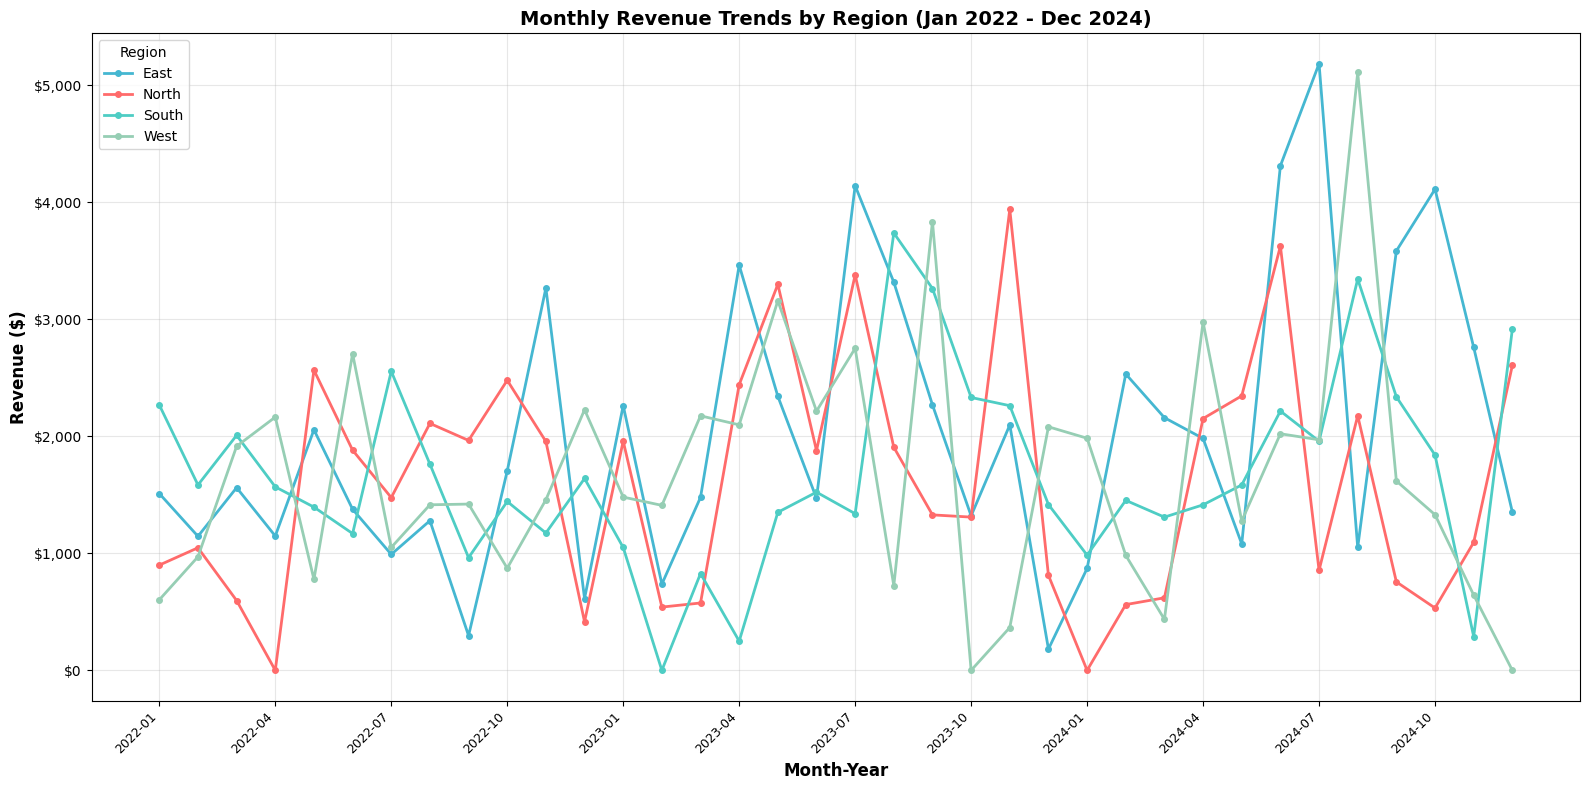


Chart saved as 'monthly_revenue_by_region.png'


In [9]:
# Create the multi-line chart
plt.figure(figsize=(16, 8))

# Define colors for each region
colors = {
    'North': '#FF6B6B',
    'South': '#4ECDC4',
    'East': '#45B7D1',
    'West': '#96CEB4'
}

# Plot each region
x_labels = [str(period) for period in monthly_revenue_by_region.index]
x = range(len(x_labels))

for region in monthly_revenue_by_region.columns:
    plt.plot(x, monthly_revenue_by_region[region], 
             label=region, 
             color=colors.get(region, 'gray'),
             linewidth=2,
             marker='o',
             markersize=4)

# Customize the chart
plt.xlabel('Month-Year', fontsize=12, fontweight='bold')
plt.ylabel('Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Monthly Revenue Trends by Region (Jan 2022 - Dec 2024)', fontsize=14, fontweight='bold')
plt.legend(title='Region', loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

# Set x-axis labels (show every 3rd month to avoid overcrowding)
plt.xticks(x[::3], x_labels[::3], rotation=45, ha='right', fontsize=9)

# Format y-axis with dollar signs
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('monthly_revenue_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'monthly_revenue_by_region.png'")

## Step 5: Bar Chart - Revenue by Category (2024 Data Only)

In [10]:
# Filter for 2024 data only
df_2024 = df[df['Transaction Date'].dt.year == 2024]

print(f"Total transactions in 2024: {len(df_2024)}")
print(f"Date range in 2024: {df_2024['Transaction Date'].min()} to {df_2024['Transaction Date'].max()}")

# Calculate revenue by category for 2024
revenue_by_category_2024 = df_2024.groupby('Category')['Transaction Amount'].sum().sort_values(ascending=False)

print("\nRevenue by Category (2024):")
display(revenue_by_category_2024)

Total transactions in 2024: 177
Date range in 2024: 2024-01-05 00:00:00 to 2024-12-29 00:00:00

Revenue by Category (2024):


Category
Books          21860.21
Health         20919.37
Home           18294.35
Electronics    17535.34
Clothing       11667.60
Name: Transaction Amount, dtype: float64

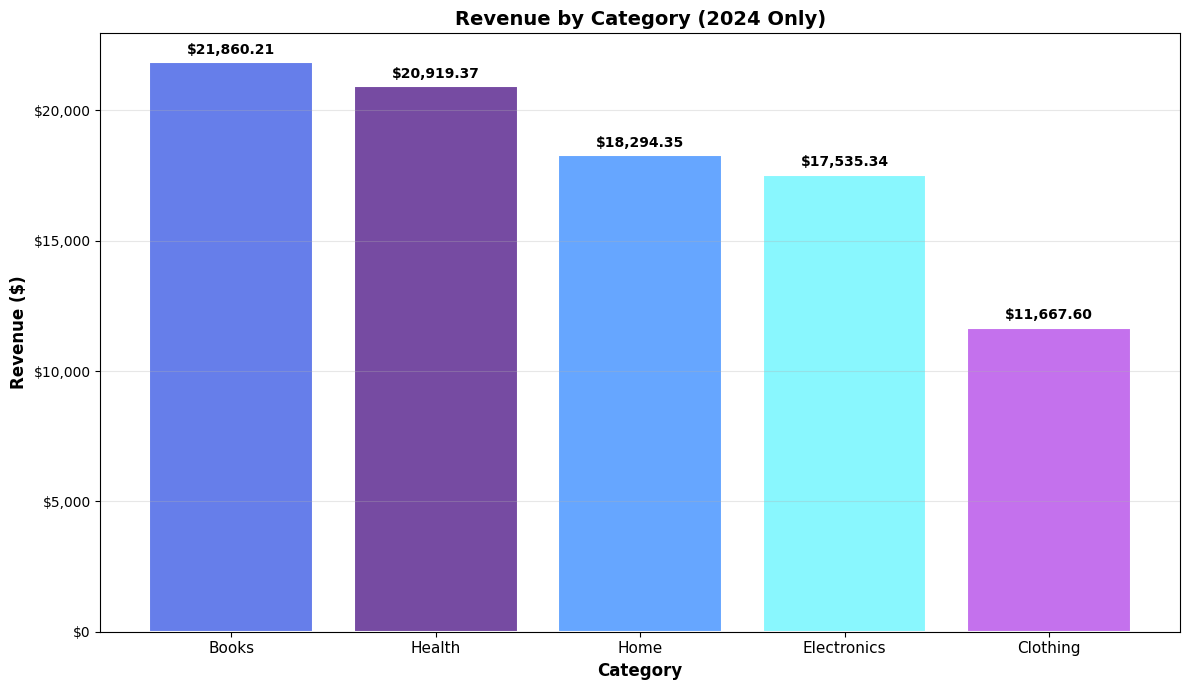


Chart saved as 'revenue_by_category_2024.png'


In [11]:
# Create the bar chart
plt.figure(figsize=(12, 7))

# Define colors for categories
category_colors = ['#667eea', '#764ba2', '#66a6ff', '#89f7fe', '#c471ed']

bars = plt.bar(revenue_by_category_2024.index, 
               revenue_by_category_2024.values,
               color=category_colors[:len(revenue_by_category_2024)],
               edgecolor='white',
               linewidth=1.5)

# Add value labels on top of bars
for bar, value in zip(bars, revenue_by_category_2024.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${value:,.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize the chart
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Revenue by Category (2024 Only)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)

# Format y-axis with dollar signs
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add grid for better readability
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_by_category_2024.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'revenue_by_category_2024.png'")

## Summary: Final Results

In [12]:
print("="*60)
print("TASK 1: FINAL RESULTS SUMMARY")
print("="*60)

print("\n📊 TOTAL REVENUE BY ENGAGEMENT TIER:")
print("-"*40)
print(f"  Revenue for 'New' customers:        ${revenue_by_tier['New']:>12,.2f}")
print(f"  Revenue for 'Active' customers:     ${revenue_by_tier['Active']:>12,.2f}")
print(f"  Revenue for 'Power User' customers: ${revenue_by_tier['Power User']:>12,.2f}")
print("-"*40)
print(f"  TOTAL REVENUE:                      ${revenue_by_tier.sum():>12,.2f}")

print("\n📈 VISUALIZATIONS CREATED:")
print("-"*40)
print("  1. Monthly Revenue Trends by Region (Jan 2022 - Dec 2024)")
print("     → Saved as 'monthly_revenue_by_region.png'")
print("  2. Revenue by Category (2024 Only)")
print("     → Saved as 'revenue_by_category_2024.png'")

print("\n" + "="*60)

TASK 1: FINAL RESULTS SUMMARY

📊 TOTAL REVENUE BY ENGAGEMENT TIER:
----------------------------------------
  Revenue for 'New' customers:        $   70,954.36
  Revenue for 'Active' customers:     $  161,816.89
  Revenue for 'Power User' customers: $   19,016.86
----------------------------------------
  TOTAL REVENUE:                      $  251,788.11

📈 VISUALIZATIONS CREATED:
----------------------------------------
  1. Monthly Revenue Trends by Region (Jan 2022 - Dec 2024)
     → Saved as 'monthly_revenue_by_region.png'
  2. Revenue by Category (2024 Only)
     → Saved as 'revenue_by_category_2024.png'



---

# Step-by-Step Methodology for Task 1

## How I Arrived at the Answer:

### **Step 1: Understanding the Problem**
- Read the task requirements carefully
- Identified key deliverables:
  - Engagement tier assignment based on purchase history
  - Revenue calculation by tier
  - Two visualization charts

### **Step 2: Data Loading and Exploration**
- Loaded the CSV file containing 500 transactions from 2022-2024
- Verified columns: Customer ID, Transaction Date, Transaction Amount, Category, Region
- Converted Transaction Date to datetime format for time-based analysis

### **Step 3: Calculating Previous Purchases**
- Sorted data by Customer ID and Transaction Date to ensure chronological order
- Used `cumcount()` within each customer group to count previous purchases
- First transaction for each customer = 0 previous purchases
- This approach ensures each transaction knows its position in the customer's purchase history

### **Step 4: Assigning Engagement Tiers**
- Applied tier logic:
  - **New**: 0 previous purchases (first-time buyer)
  - **Active**: 1-4 previous purchases (returning customer)
  - **Power User**: 5+ previous purchases (loyal customer)
- Each row gets a tier based on purchase history **at that point in time**

### **Step 5: Revenue Calculation**
- Grouped transactions by Engagement Tier
- Summed Transaction Amount for each tier
- Rounded results to 2 decimal places

### **Step 6: Creating Visualizations**
- **Chart 1 (Multi-line)**: Aggregated monthly revenue by Region, plotted trends over time
- **Chart 2 (Bar)**: Filtered 2024 data, calculated revenue by Category, created bar chart

### **Key Insights:**
- The tier assignment is **transaction-level**, not customer-level
- A customer can have transactions in different tiers over time as they make more purchases
- This provides insights into how customers contribute at different stages of their journey